In [1]:
import json
import torch

from core.models.LightningDiT import LightningDiT, LightningDiTConfig
from core.custom_datasets.pokemon_dataset import PokemonDataset
from core.training.train_transformer import train_drifting
from core.models.utils import prepare_vae, get_number_of_parameters

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMG_SIZE = 128

In [3]:
vae_name = "flux-vae"

vae_kwargs = {
    "device_map": "cuda:0",
    "torch_dtype": torch.bfloat16,
}

vae, latent_shape = prepare_vae(
    vae_name="flux_vae",
    path_to_vae="./checkpoints/flux_vae",
    img_size=IMG_SIZE,
    vae_kwargs=vae_kwargs
)

print("VAE:")
get_number_of_parameters(vae)

vae = torch.compile(vae, mode="reduce-overhead")

VAE:
Params: 84M


In [4]:
# config_path = "/home/msst/repo/drifting/checkpoints/config_ViT-B2_flux-vae_128.json"
# with open(config_path, "r") as f:
#     config_dict = json.load(f)

# vit_config = LightningDiTConfig.from_dict(config_dict)
# vit = LightningDiT(vit_config).cuda()

vit = LightningDiT.from_pretrained(
    "/home/msst/repo/drifting/checkpoints/CelebA/transformer_img128_ps2_flux-vae_newloss/save_transformer_step2000"
).cuda()

opt = torch.optim.AdamW(
    vit.parameters(), 
    lr=2e-4,
    betas=(0.9, 0.95),
    weight_decay=0.02,
)

In [5]:
from accelerate import init_empty_weights
from core.models.advanced_deature_encoder import FeatureExtractor, MAEResNet

with init_empty_weights():
    mae_resnet = MAEResNet(
            in_channels = latent_shape[0],
            base_channels = 384,
            mask_patch_size = 2,
            input_patch_size = 1,
            layers = (3, 4, 6, 3),
        )
mae_resnet = mae_resnet.to_empty(device="cuda:0")
mae_resnet = torch.compile(mae_resnet, mode="reduce-overhead")
mae_resnet.load_state_dict(
    torch.load(
        "/home/msst/repo/drifting/checkpoints/CelebA/MAE_flux-vae_ch384_img128/CelebA/epochs92.pth"
        )
    )
feature_encoder = FeatureExtractor(
    encoder=mae_resnet.encoder.to(torch.bfloat16).cuda(),
    input_patch_size=mae_resnet.input_patch_size,
    every_k_block=2
)

print("Feature encoder:")
get_number_of_parameters(feature_encoder)

Feature encoder:
Params: 766M


In [6]:
dataset_path = "/home/msst/repo/drifting/data/CelebA"
dataset_type = "FACES"

dataset = PokemonDataset(
    root_dir=dataset_path, 
    img_size=IMG_SIZE, 
    dataset_type=dataset_type
)

Number of images: 202599


Saved image to checkpoints/CelebA/transformer_img128_ps2_flux-vae_newloss/gen_images_1.png


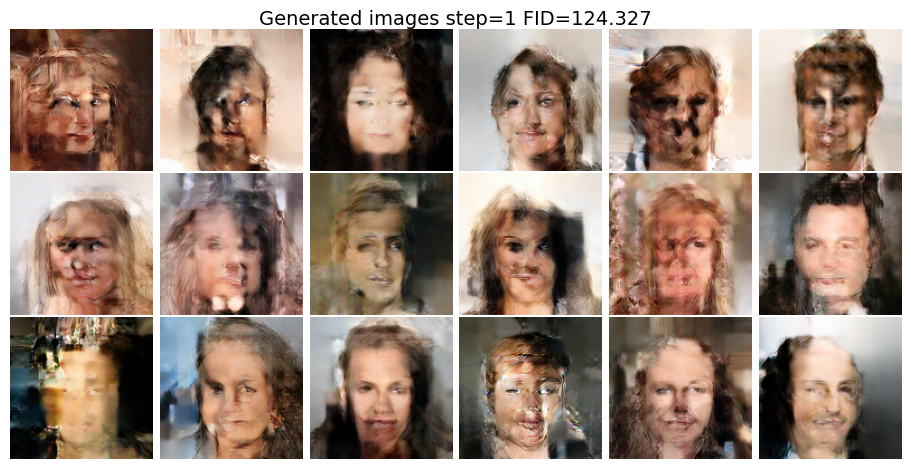

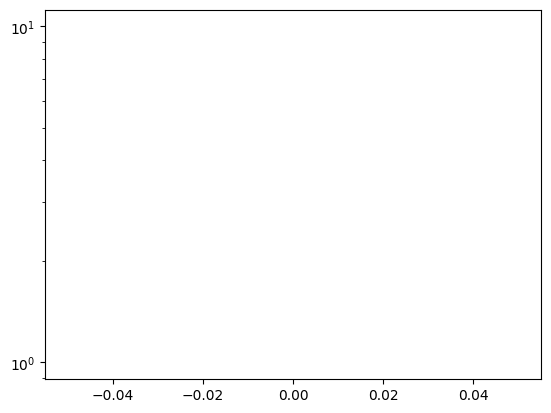

  0%|          | 95/100000 [01:22<15:50:54,  1.75it/s, loss=1.23e+00]

In [ ]:
train_drifting(
        dataset=dataset,
        feature_encoder=feature_encoder,
        transformer=vit,
        vae=vae,
        opt=opt,
        noise_shape=latent_shape,
        T_list=[0.02, 0.05, 0.2],
        batch_size=128,
        gradient_accumulation=1,
        training_steps=10**5,
        val_step=250,
        samples_to_compute_fid=2048,
        seed=None,
        save_step=1000,
        loss_scaling=1.0e3,
        training_device="cuda:0",
        training_dtype=torch.bfloat16,
        save_path=f"checkpoints/CelebA/transformer_img{IMG_SIZE}_ps{vit.patch_size}_{vae_name}_newloss",
    )
